In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from glob import glob
from matplotlib import rcParams

from theme import colors


In [3]:
results_dir = "results/data"

# reload results
df = pd.concat([pd.read_csv(fp) for fp in glob(os.path.join(results_dir, "*.csv"))])

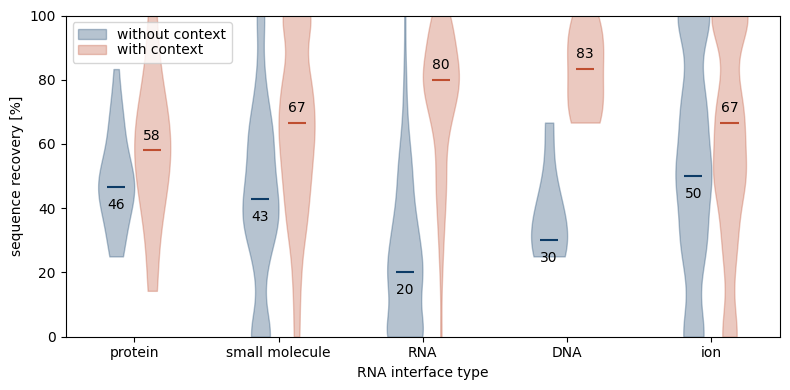

In [4]:
keys = ['protein', 'ligand', 'rna', 'dna', 'ion']
labels = ['protein', 'small molecule', 'RNA', 'DNA', 'ion']
# plot data
x = np.arange(len(keys))
ys_l = [1e2*df[(df['context_level'] == 0) & (df['binder_type'] == k)]['recovery_rate'].values for k in keys]
yc_l = [1e2*df[(df['context_level'] == 2) & (df['binder_type'] == k)]['recovery_rate'].values for k in keys]

# plot
plt.figure(figsize=(8,4))
vps = plt.violinplot(ys_l, 2*x, showextrema=False, showmedians=True, widths=0.5)
vps['cmedians'].set_edgecolor(colors[1])
for pc in vps['bodies']:
    pc.set_facecolor(colors[1])
    pc.set_edgecolor(colors[1])
vpc = plt.violinplot(yc_l, 2*x+0.5, showextrema=False, showmedians=True, widths=0.5)
vpc['cmedians'].set_edgecolor(colors[0])
for pc in vpc['bodies']:
    pc.set_facecolor(colors[0])
    pc.set_edgecolor(colors[0])
plt.ylim(0.0, 1e2)
plt.xticks(2*x+0.25, labels)
for i in range(len(ys_l)):
    mys = np.median(ys_l[i])
    myc = np.median(yc_l[i])
    plt.text(2*x[i], mys-5.0, '{:.0f}'.format(mys), va='center_baseline', ha='center', size=10)
    plt.text(2*x[i]+0.5, myc+5.0, '{:.0f}'.format(myc), va='center_baseline', ha='center', size=10)
legends = [
    (mpatches.Patch(color=vps["bodies"][0].get_facecolor().flatten()), "without context"),
    (mpatches.Patch(color=vpc["bodies"][0].get_facecolor().flatten()), "with context"),
]
plt.legend(*zip(*legends), loc="upper left", prop={'size': 10}, labelspacing=0.1)
plt.xlabel("RNA interface type")
plt.ylabel("sequence recovery [%]")
plt.tight_layout()
# Save or display the plot
plt.savefig("results/sequence_recovery_interfaces.svg")
plt.savefig("results/sequence_recovery_interfaces.png", dpi=300)
plt.savefig("results/sequence_recovery_interfaces.pdf", dpi=300)
plt.show()

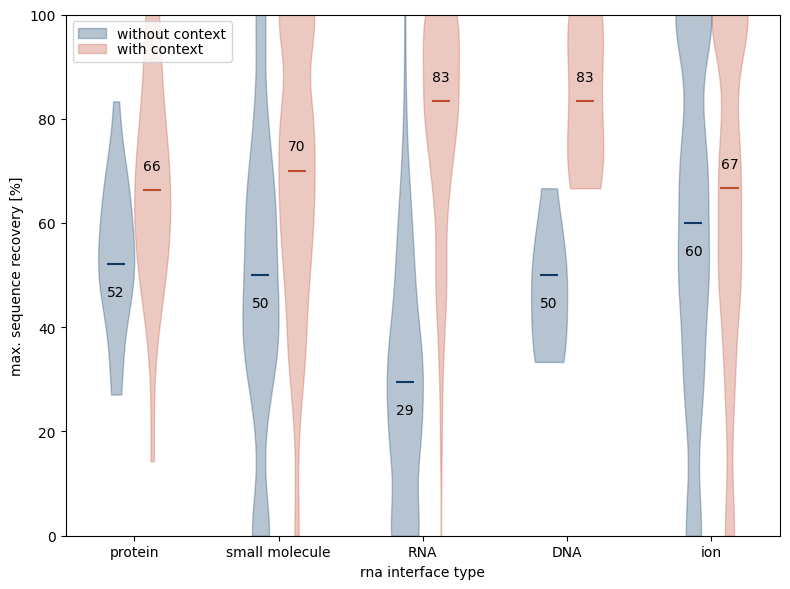

In [5]:
keys = ['protein', 'ligand', 'rna', 'dna', 'ion']
labels = ['protein', 'small molecule', 'RNA', 'DNA', 'ion']
# plot data
x = np.arange(len(keys))
ys_l = [1e2*df[(df['context_level'] == 0) & (df['binder_type'] == k)]['maximum_recovery_rate'].values for k in keys]
yc_l = [1e2*df[(df['context_level'] == 2) & (df['binder_type'] == k)]['maximum_recovery_rate'].values for k in keys]

# plot
plt.figure(figsize=(8,6))
vps = plt.violinplot(ys_l, 2*x, showextrema=False, showmedians=True, widths=0.5)
vps['cmedians'].set_edgecolor(colors[1])
for pc in vps['bodies']:
    pc.set_facecolor(colors[1])
    pc.set_edgecolor(colors[1])
vpc = plt.violinplot(yc_l, 2*x+0.5, showextrema=False, showmedians=True, widths=0.5)
vpc['cmedians'].set_edgecolor(colors[0])
for pc in vpc['bodies']:
    pc.set_facecolor(colors[0])
    pc.set_edgecolor(colors[0])
plt.ylim(0.0, 1e2)
plt.xticks(2*x+0.25, labels)
for i in range(len(ys_l)):
    mys = np.median(ys_l[i])
    myc = np.median(yc_l[i])
    plt.text(2*x[i], mys-5.0, '{:.0f}'.format(mys), va='center_baseline', ha='center', size=10)
    plt.text(2*x[i]+0.5, myc+5.0, '{:.0f}'.format(myc), va='center_baseline', ha='center', size=10)
legends = [
    (mpatches.Patch(color=vps["bodies"][0].get_facecolor().flatten()), "without context"),
    (mpatches.Patch(color=vpc["bodies"][0].get_facecolor().flatten()), "with context"),
]
plt.legend(*zip(*legends), loc="upper left", prop={'size': 10}, labelspacing=0.1)
plt.xlabel("rna interface type")
plt.ylabel("max. sequence recovery [%]")
plt.tight_layout()
# Save or display the plot
# Save the plot
plt.savefig("results/maximum_sequence_recovery_interfaces.svg")
plt.savefig("results/maximum_sequence_recovery_interfaces.png", dpi=300)
plt.show()